# Mínimos quadrados em dados sintéticos

**Autor:** Prof. Dr. Sergio Antônio Andrade de Freitas  
**Material da disciplina:** FGA0083 — Aprendizado de Máquina, UnB

## Objetivo e dados

Recuperar aproximadamente nota inicial 5 e ganho de 0,5 por hora.

**Pergunta-guia:** Quanto os coeficientes estimados se afastam dos parâmetros usados para gerar os dados?

Execute as células na ordem e interprete os resultados antes de fazer o exercício.

Intercepto estimado: 5.215; ganho/hora: 0.454


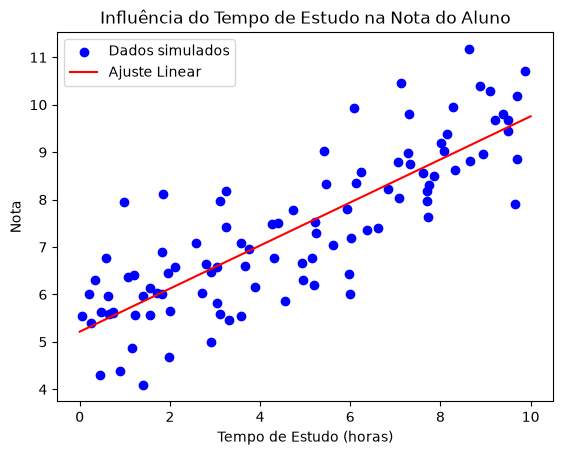

array([[5.21509616],
       [9.75532293]])

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Passo 1: Gerar Dados Sintéticos
np.random.seed(42)  # Semente para reprodutibilidade
tempo_de_estudo = 10 * np.random.rand(100, 1)  # Tempo de estudo entre 0 e 10 horas
nota_base = 5  # Nota base assumida sem estudo
nota_por_hora = 0.5  # Ganho de nota por hora de estudo

notas = nota_base + nota_por_hora * tempo_de_estudo + np.random.randn(100, 1)  # Notas simuladas

# Passo 2: Cálculo dos Coeficientes com Mínimos Quadrados
X_b = np.c_[np.ones((100, 1)), tempo_de_estudo]  # Adicionando termo de interceptação
theta_best = np.linalg.lstsq(X_b, notas, rcond=None)[0]
print(f'Intercepto estimado: {theta_best[0, 0]:.3f}; ganho/hora: {theta_best[1, 0]:.3f}')

# Passo 3: Visualização dos Dados e do Ajuste Linear
plt.scatter(tempo_de_estudo, notas, color='blue', label='Dados simulados')
line_x = np.linspace(0, 10, 100).reshape(100, 1)
line_y = theta_best[0] + theta_best[1] * line_x
plt.plot(line_x, line_y, color='red', label='Ajuste Linear')
plt.xlabel('Tempo de Estudo (horas)')
plt.ylabel('Nota')
plt.title('Influência do Tempo de Estudo na Nota do Aluno')
plt.legend()
plt.show()

# Passo 4: Predição de Notas com o Modelo
X_new = np.array([[0], [10]])  # Aluno que não estudou e aluno que estudou 10 horas
X_new_b = np.c_[np.ones((2, 1)), X_new]
notas_previstas = X_new_b.dot(theta_best)

notas_previstas

## Investigação complementar

Compare a nova medida com a figura ou o resultado anterior. Explique qualquer diferença observada.

In [2]:
print('Parâmetros usados na geração: intercepto=5; ganho por hora=0.5')
print('Estimativas:', theta_best.ravel().round(3))
print('Erro médio absoluto:', np.mean(np.abs(notas - X_b @ theta_best)).round(3))

Parâmetros usados na geração: intercepto=5; ganho por hora=0.5
Estimativas: [5.215 0.454]
Erro médio absoluto: 0.701


## Interpretação e limites

A inversão explícita da matriz normal pode ser instável; o exemplo passa a usar mínimos quadrados numéricos.

## Exercício

Altere o nível de ruído e compare erro e coeficientes. Use `data/4.2 - dados_aluguel_bicicletas.csv` como extensão, documentando as unidades.

Registre a hipótese, a mudança realizada, a métrica ou figura observada e uma conclusão que os dados de fato sustentem.